In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base = pd.read_csv('datos\\hour.csv')
base.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Punto 1

La variable X, que es el número total de bicicletas rentadas, es discreta, ya que sólo podemos tomar valores enteros de bicicletas, es decir, no podríamos tomar 1.2 bicicletas porque no tiene sentido y el rango sería el valor mínimo y valor máximo que puede tomar dicha variable, es decir, puede ir de 0 al número máximo de bicicletas que tengan, pero a continuación se calculará cual es.

In [3]:
max_bicis = base['cnt'].max()
min_bicis = base['cnt'].min()
tipo_bicis = base['cnt'].dtype

print(f'El tipo de la variable es X {tipo_bicis}, es decir es discreto')
print(f'El rango de la variable X es {{{min_bicis}, {max_bicis}}}')

El tipo de la variable es X int64, es decir es discreto
El rango de la variable X es {1, 977}


La variable T, que es la temperatura registrada, es continua, ya que es imposible que la temperatura tenga saltos, es decir, la temperatura no salta de 23°C a 24°C, si no que debe de subir progresivamente de 23°C hasta 24°C, aunque este normalizada, sigue siendo continua, y su rango estaría dentro de los límites historicos de la ciudad, pero debido a que está normalizada la variable, su rango seria de 0 a 1, a continuación se verificará:

In [4]:
max_temp = base['temp'].max()
min_temp = base['temp'].min()
tipo_temp = base['temp'].dtype

print(f'El tipo de la variable es X {tipo_temp}, es decir es continuo')
print(f'El rango de la variable X es {{{min_temp}, {max_temp}}}')

El tipo de la variable es X float64, es decir es continuo
El rango de la variable X es {0.02, 1.0}


De igual manera la variable H, que es la humedad registrada, es continua, por la misma razón que no da saltos, independientemente que este normalizada, que en este caso sólo se normalizó diviendiendo entre 100, ya que el rango normal de la humedad va de 0 a 100, pero acontinuación se calculará el rango.

In [5]:
max_hum = base['hum'].max()
min_hum = base['hum'].min()
tipo_hum = base['hum'].dtype

print(f'El tipo de la variable es X {tipo_hum}, es decir es continuo')
print(f'El rango de la variable X es {{{min_hum}, {max_hum}}}')

El tipo de la variable es X float64, es decir es continuo
El rango de la variable X es {0.0, 1.0}


a) como se pudo observar antes, para la variable X la columna asociada es 'cnt', para la variable T es 'temp' y por último para la variable H es 'hum'

b) el experimento asociado a estas 3 variables es seleccionar al azar un registro de la base de datos.

c) una columna de datos es un registro de todos los datos que ya pasaron, es decir, es un valor fijo que ya no se puede cambiar porque ya lo conocemos, mientras que una variable aleatoria son los posibles resultados de un registro que aún no ocurre, por lo que la principal diferencia es que uno ya paso y el otro aún no y queremos predecirlo.

d) la variable aleatoria X son los posibles resultados de un experimento, que aún no pasa, la observación X = 178 es aquel resultado que ya sucedió y que sabemos su valor exacto, y la columna de datos como 'cnt' es la colección de resultados que ya pasaron y que sabemos cuanto valen exactamente. 

### Punto 2

##### a)

Para saber el total de bicis son rentadas en una hora, debemos saber cuantos valores puede tomar X, es decir, su rango, para ello usamos la función value_counts y la normalizamos para obtener frecuencias relativas

In [ ]:
bicis_en_hora = base['cnt'].value_counts(normalize=True).sort_index()
bicis_en_hora = bicis_en_hora.to_frame('Frecuencias').reset_index(names='X') # recordemos que X es la columna cnt
bicis_en_hora

,X,Frecuencias
0,1,0.009091
1,2,0.011968
2,3,0.012889
3,4,0.013292
4,5,0.014961
...,...,...
864,967,0.000058
865,968,0.000058
866,970,0.000058
867,976,0.000058


##### b)

Text(0, 0.5, 'Frecuencia relativa')

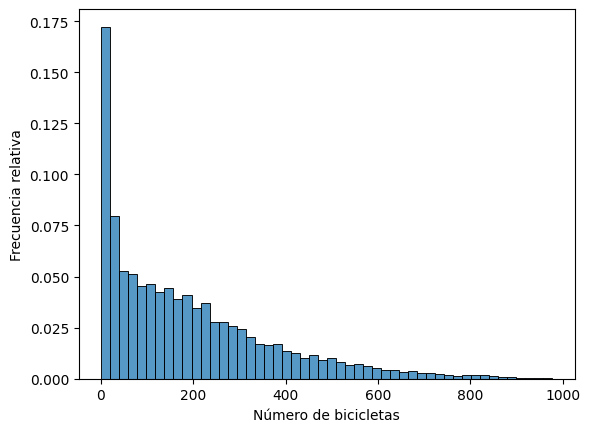

In [7]:
sns.histplot(data=bicis_en_hora, x='X', weights='Frecuencias', bins=50)
plt.xlabel('Número de bicicletas')
plt.ylabel('Frecuencia relativa')

#### c)

Se construyó tanto una función para saber la función de distribución del total de bicicletas, como un columna del total acumulado para que la gráfica pueda construirse rápido

In [8]:
def distribucion_empirica(num):
    probabilidades = bicis_en_hora[bicis_en_hora['X']<=num]    
    return probabilidades['Frecuencias'].sum()

print(distribucion_empirica(970))

bicis_en_hora['Acumulado'] = bicis_en_hora['Frecuencias'].cumsum()
bicis_en_hora

0.9998849185798953


,X,Frecuencias,Acumulado
0,1,0.009091,0.009091
1,2,0.011968,0.021060
2,3,0.012889,0.033949
3,4,0.013292,0.047241
4,5,0.014961,0.062202
...,...,...,...
864,967,0.000058,0.999770
865,968,0.000058,0.999827
866,970,0.000058,0.999885
867,976,0.000058,0.999942


Text(0, 0.5, 'Frecuencia acumuluda')

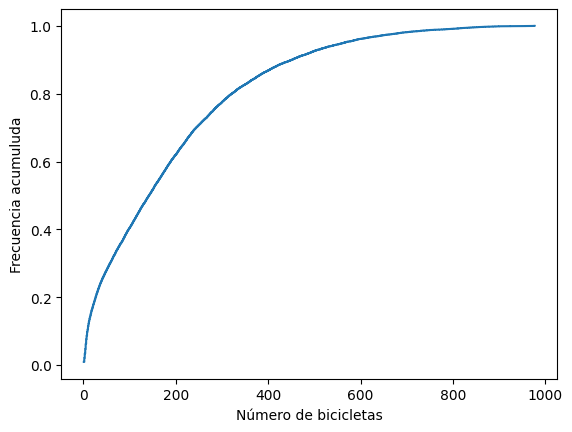

In [42]:
plt.step(bicis_en_hora['X'], bicis_en_hora['Acumulado'],where='post')
plt.xlabel('Número de bicicletas')
plt.ylabel('Frecuencia acumuluda')

##### d)

añadimos la frecuencia absoluta para tener el número exacto de bicicletas

In [10]:
frec_abs = base['cnt'].value_counts().sort_index()
bicis_en_hora['Frecuencia abs'] = frec_abs.values
bicis_en_hora.nlargest(1, 'Frecuencia abs')

,X,Frecuencias,Acumulado,Frecuencia abs
4,5,0.014961,0.062202,260


##### e)

filtramos los registros que superen el acumulado y extraemos el primer valor de X que lo supere

In [11]:
cuantiles = [0.25, 0.50, 0.75, 0.90, 0.95]

def obtener_cuantiles(cuantiles):
    valores = []
    for cuantil in cuantiles:
        datos = bicis_en_hora[bicis_en_hora['Acumulado']>=cuantil] # de esta forma garantizamos que se supere el umbral del cuantil
        valores.append(float(datos.iloc[0,0]))
    return valores

valores = obtener_cuantiles(cuantiles)
valores

[40.0, 142.0, 281.0, 452.0, 564.0]

##### f)

La mayoría de las horas registran una demanda baja, porque el cuantil 0.5 de las horas registran menos de 142 bicicletas. Existe una larga 'cola' hacia la derecha que representa alta demanda elevando el cuantil 0.95 hasta 564 bicicletas. La distribución no es simétrica.

### Punto 3

a)

In [12]:
def probabilidad(x):
    acum= bicis_en_hora[bicis_en_hora['X']<=x]
    return float(acum.iloc[-1,2])

P_X_menor_igual_100 = probabilidad(100)
P_X_mayor_300 = 1 - probabilidad(300)
P_100_menor_X_menor_igual_300 = probabilidad(300) - probabilidad(100)

print(f"P(X > 300) = {P_X_mayor_300}")
print(f"P(100 < X <= 300) = {P_100_menor_X_menor_igual_300}")
print(f"P(X <= 100) = {P_X_menor_igual_100}")

P(X > 300) = 0.22389090281374113
P(100 < X <= 300) = 0.3713102019678921
P(X <= 100) = 0.40479889521836676


##### b)

efectivamente los 3 eventos forman una partición adecuada, debido a que no se traslapan, es decir, un mismo registro no puede estar en 2 3 de esos 3 eventos a la vez, ade más cubren todos los posibles resultados del total de bicicletas, a continuación se comprobará con una suma

In [13]:
suma = P_X_menor_igual_100 + P_X_mayor_300 +P_100_menor_X_menor_igual_300
suma

1.0

##### c) 

Para P(X <= 100): Esta probabilidad representa las horas de baja demanda en el sistema. Operativamente, esto puede corresponder a horarios nocturnos, madrugadas o momentos con condiciones climáticas muy adversas donde casi no hay usuarios rentando bicicletas.

Para P(100 < X <= 300): La probabilidad en este intervalo representa el flujo regular o demanda moderada del sistema. Es el comportamiento promedio esperado durante la mayor parte de las horas hábiles del día.

Para P(X > 300): Esta probabilidad representa los picos de alta demanda. Aunque es el porcentaje más pequeño, es la métrica más crítica para el negocio, ya que refleja las horas pico (como entrada/salida de oficinas) donde el sistema podría quedarse sin bicicletas disponibles y requiere mayor esfuerzo de disponibilidad.

### Punto 4

##### a) 

In [22]:
q_75 = obtener_cuantiles([0.75])
# q_75 = base['cnt'].quantile(0.75)
print(f"El percentil 75 es: {q_75} bicicletas")

base['D'] = (base['cnt'] > q_75[0]).astype(int)
base.head()


El percentil 75 es: [281.0] bicicletas


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,D
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,0


##### b)

In [ ]:
dist_D = base['D'].value_counts(normalize=True).sort_index()
dist_D = dist_D.to_frame('Frecuencias').reset_index(names='D')
dist_D

,D,Frecuencias
0,0,0.751079
1,1,0.248921


##### c)

In [25]:
P_D_igual_0 = dist_D.iloc[0,1]
P_D_igual_1 = dist_D.iloc[1,1]

print(f"P(D = 0) = {P_D_igual_0}")
print(f"P(D = 1) = {P_D_igual_1}")

P(D = 0) = 0.7510788883134818
P(D = 1) = 0.2489211116865182


##### d)

La distribución que podemos utilizar sería la Bernoulli ya que nos ayuda a describir un experimiento aleatorio como éxito o fracaso, es decir, 2 posibles resultados.

##### e)

La distribución bernoulli tiene como parámetro a 'p' que es la proabilidad de tener éxito que en este caso en 1 y como sabemos y calculamos en este caso sería p=0.249. Por lo tanto, nos quiere decir que si elegimos una hora al azar tenemos casi un 25% de que se clasifique como alta demanda.

### Punto 5

##### a)

Aqui observamos algo importante en las probabilidades que se piden, al filtrar la condición dada, en la columna D solo podemos tener 1 o 0, y si le sacamos el promedio a la columna D, pandas lo que hará será sólo sumar los 1's, pero los dividirá entre el total, sin importar si son 0's o 1's y concide justo en como sacar la probabilidad conidicional.

In [26]:
P_D1_dado_working1 = base[base['workingday'] == 1]['D'].mean()
P_D1_dado_working0 = base[base['workingday'] == 0]['D'].mean()
P_D1_dado_weather1 = base[base['weathersit'] == 1]['D'].mean()
P_D1_dado_weather_bad = base[base['weathersit'] >= 2]['D'].mean()

print(f"P(D=1 | workingday=1) = {P_D1_dado_working1}")
print(f"P(D=1 | workingday=0) = {P_D1_dado_working0}")
print(f"P(D=1 | weathersit=1) = {P_D1_dado_weather1}")
print(f"P(D=1 | weathersit>=2) = {P_D1_dado_weather_bad}")

P(D=1 | workingday=1) = 0.24391066160977665
P(D=1 | workingday=0) = 0.259702575262967
P(D=1 | weathersit=1) = 0.2816086918426356
P(D=1 | weathersit>=2) = 0.1863895407308079


##### b)

Notamos que la diferencia entre la probabilidad entre dias laborales y no, realmente no es muy alta, lo que nos podría hacer idea que el uso de las bicicletas es fuerte tanto para ir al trabajo como recreativas en un fin de semana.

##### c)

Aqui si notamos una diferencia más notable, es decir, cuando el clima es favorable (weathersit = 1) hay mayor probabilidad de tener alta demanda en el uso de la bicicleta, mientras que cuando hay lluvias, frios, etc (weathersit >= 1), la probabilidad de tener demandas altas de bicicleta son menos probables.

##### d)

Porque la probabilidad no condicionada incluye todos los registros, tanto los días con buen clima, como los que no, como días laborales y no, es decir, es entre toda la población, mientras que una condicional, restringue los registros que estarán en la población, es decir, reduce la población pero nos traé mayor información y podremos saber mejor una probabilidad conociendo otra información.

### Punto 6

##### a)

In [ ]:
temp_en_hora = base['temp'].value_counts(normalize=True).sort_index()
temp_en_hora = temp_en_hora.to_frame('Frecuencias').reset_index(names='temp')
temp_en_hora.head()

,temp,Frecuencias
0,0.02,0.000978
1,0.04,0.000921
2,0.06,0.000921
3,0.08,0.000978
4,0.10,0.002935


Text(0, 0.5, 'Frecuencia relativa')

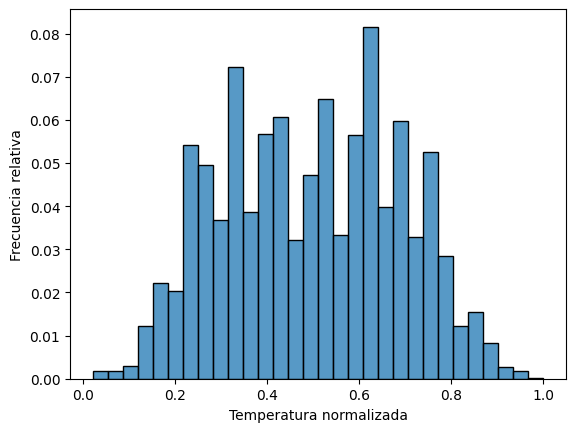

In [36]:
sns.histplot(data=temp_en_hora, x='temp', weights='Frecuencias', bins=30)
plt.xlabel('Temperatura normalizada')
plt.ylabel('Frecuencia relativa')

Text(0, 0.5, 'Frecuencia acumuluda')

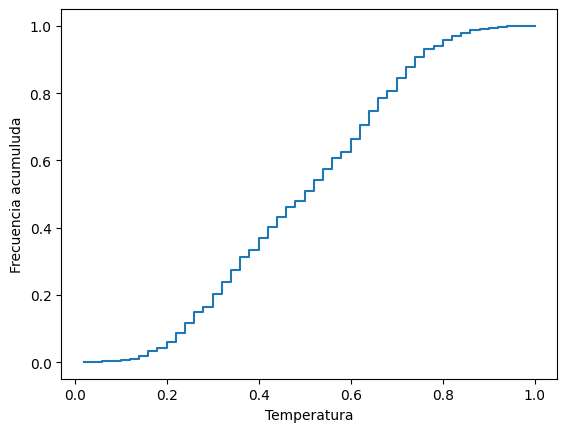

In [41]:
temp_en_hora['Acumulado'] = temp_en_hora['Frecuencias'].cumsum()

plt.step(temp_en_hora['temp'], temp_en_hora['Acumulado'],where='post')
plt.xlabel('Temperatura')
plt.ylabel('Frecuencia acumuluda')

##### b)

In [43]:
cuantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

def obtener_cuantiles(cuantiles):
    valores = []
    for cuantil in cuantiles:
        datos = temp_en_hora[temp_en_hora['Acumulado']>=cuantil] # de esta forma garantizamos que se supere el umbral del cuantil
        valores.append(float(datos.iloc[0,0]))
    return valores

valores = obtener_cuantiles(cuantiles)
valores

[0.24, 0.34, 0.5, 0.66, 0.74]

##### c)

Sea el rango de las temperaturas entre 0.2 y 0.4

In [46]:
def probabilidad(t):
    acum= temp_en_hora[temp_en_hora['temp']<=t]
    return float(acum.iloc[-1,2])

P_02_menor_X_menor_igual_04 = probabilidad(0.4) - probabilidad(0.2)

print(f"P(0.2 < t <= 0.4) = {P_02_menor_X_menor_igual_04}")


P(0.2 < t <= 0.4) = 0.30824558375050354


También sea el rango de 0.6 y 0.8

In [51]:
P_06_menor_X_menor_igual_08 = probabilidad(0.8) - probabilidad(0.6)

print(f"P(0.6 < t <= 0.8) = {P_06_menor_X_menor_igual_08}")

P(0.6 < t <= 0.8) = 0.294953679728408


##### d)

Text(0, 0.5, 'Probabilidad')

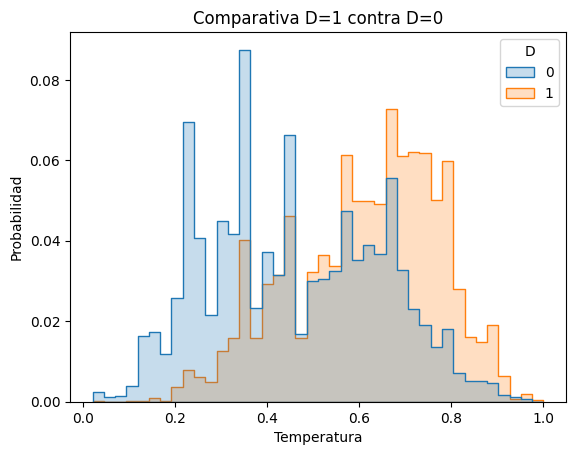

In [56]:
sns.histplot(data=base, x='temp', hue='D', stat='probability', 
            common_norm=False, element='step')
plt.title('Comparativa D=1 contra D=0')
plt.xlabel('Temperatura')
plt.ylabel('Probabilidad')

##### e)

Al analizar la gráfica, vemos que la distribución de temperaturas cuando hay alta demanda (D=1) está desplazada hacia la derecha en comparación con D=0, por lo que nos indica que, es mucho más probable alcanzar niveles máximos de renta cuando las temperaturas son más cálidas, mientras que la distribución de D=0 tiene mayor masa de probabilidad en el lado izquierdo de la gráfica, confirmando que las temperaturas frías están asociadas con escenarios de baja demanda.